# Dunkelflaute batteri-lab

Dette notebooket lar deg skalere en hypotetisk europeisk batteripark for en flerdagers **Dunkelflaute**: en periode der vind og sol er lave over store områder samtidig.

Poenget er ikke å bevise at batterier er dårlige. Poenget er å skille mellom:

1. batterier som svært nyttig **korttidsfleksibilitet**, og  
2. batterier som hovedløsning for **kontinental, flerdagers energireserve**.

Modellen er enkel med vilje. Den skal gi størrelsesorden, ikke optimalisere kraftsystemet.

> Termer og forkortelser (BESS, LFP, NTC, LCOS, Dunkelflaute m.fl.) er samlet i [`ORDLISTE.md`](../ORDLISTE.md) i repo-roten.


## Mental modell

Vi beregner først energimengden som mangler:

$$
E_{levert} = P_{residual} \times 24 \times d
$$

Deretter skalerer vi opp til installert batterikapasitet:

$$
E_{installert} = \frac{E_{levert}}{u}
$$

hvor:

- $P_{residual}$ = effektmangel i GW etter alt annet som fortsatt virker
- $d$ = antall døgn hendelsen varer
- $u$ = utnyttbar andel av installert batteri, etter marginer, drift, degradering og reserve

Det viktige grepet er å bruke **residual gap**, ikke total last. Hvis kjernekraft, vannkraft, import, bioenergi, backup, fleksibelt forbruk og noe restproduksjon dekker mye, faller batteribehovet kraftig. Hvis de ikke gjør det, eksploderer TWh-tallet.

## Standardverdier og kilder

Standardverdiene er ment som nøkterne 2025/2026-ankere, ikke som fasit.

- Ember: EU-fornybart i 2025 var 1 331 TWh og 47,7 % av kraften. Det impliserer ca. 2 790 TWh/år total elektrisitet, eller ca. 318 GW snittlast.
- SolarPower Europe: EU installerte 27,1 GWh ny BESS i 2025.
- IEA: global battericellekapasitet var over 3 TWh/år i 2024; forpliktede prosjekter kan gi ca. 6,5 TWh/år i 2030.
- BNEF: stationary storage pack cost rundt 70 USD/kWh i 2025.
- Energy-Storage.news/BNEF: turnkey BESS rundt 117 USD/kWh i 2025.
- USGS: global litiumproduksjon 2025 ca. 290 000 tonn, ekskl. USA.
- ICCT: LFP-celler krever omtrent 0,09 kg litium per kWh.
- IEA: natrium-ion kan diversifisere på sikt, men dagens og annonserte kapasitet er svært Kina-konsentrert.

Kildelisten ligger også i `data/defaults.json`.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# Gjør notebooket robust både fra repo-roten og fra notebooks/-mappen.
HERE = Path.cwd()
DEFAULTS_PATHS = [
    HERE / "data" / "defaults.json",
    HERE.parent / "data" / "defaults.json",
]
for path in DEFAULTS_PATHS:
    if path.exists():
        DEFAULTS_PATH = path
        break
else:
    raise FileNotFoundError("Fant ikke data/defaults.json")

assumptions = json.loads(DEFAULTS_PATH.read_text(encoding="utf-8"))
defaults = assumptions["defaults"]
defaults

{'eu_annual_electricity_twh': 2790.0,
 'average_load_gw': 318.0,
 'residual_gap_gw': 250.0,
 'event_days': 10.0,
 'usable_fraction': 0.8,
 'stationary_pack_cost_usd_per_kwh': 70.0,
 'turnkey_bess_cost_usd_per_kwh': 117.0,
 'lfp_share': 0.75,
 'sodium_ion_share': 0.15,
 'other_long_duration_share': 0.1,
 'lfp_lithium_intensity_kg_per_kwh': 0.09,
 'global_lithium_production_tonnes_2025': 290000.0,
 'global_battery_cell_manufacturing_capacity_twh_2024': 3.0,
 'committed_global_cell_capacity_twh_2030': 6.5,
 'eu_bess_additions_gwh_2025': 27.1}

In [2]:
def normalize_mix(lfp, sodium, other):
    total = lfp + sodium + other
    if total <= 0:
        raise ValueError("Kjemimiksen må ha positiv sum.")
    return lfp / total, sodium / total, other / total


def calculate(
    residual_gap_gw=defaults["residual_gap_gw"],
    event_days=defaults["event_days"],
    usable_fraction=defaults["usable_fraction"],
    pack_cost_usd_per_kwh=defaults["stationary_pack_cost_usd_per_kwh"],
    turnkey_cost_usd_per_kwh=defaults["turnkey_bess_cost_usd_per_kwh"],
    lfp_share=defaults["lfp_share"],
    sodium_ion_share=defaults["sodium_ion_share"],
    other_long_duration_share=defaults["other_long_duration_share"],
    lfp_lithium_intensity_kg_per_kwh=defaults["lfp_lithium_intensity_kg_per_kwh"],
    global_lithium_production_tonnes_2025=defaults["global_lithium_production_tonnes_2025"],
    global_cell_capacity_twh_per_year=defaults["global_battery_cell_manufacturing_capacity_twh_2024"],
    eu_bess_additions_gwh_per_year=defaults["eu_bess_additions_gwh_2025"],
):
    """Returnerer nøkkeltall for en enkel Dunkelflaute-batterimodell."""
    if usable_fraction <= 0 or usable_fraction > 1:
        raise ValueError("usable_fraction må være i intervallet (0, 1].")

    lfp, sodium, other = normalize_mix(
        lfp_share, sodium_ion_share, other_long_duration_share
    )

    delivered_twh = residual_gap_gw * 24 * event_days / 1000
    installed_twh = delivered_twh / usable_fraction

    pack_cost_trillion_usd = installed_twh * pack_cost_usd_per_kwh / 1000
    turnkey_cost_trillion_usd = installed_twh * turnkey_cost_usd_per_kwh / 1000

    lfp_twh = installed_twh * lfp
    sodium_twh = installed_twh * sodium
    other_twh = installed_twh * other

    lithium_tonnes = lfp_twh * 1_000_000_000 * lfp_lithium_intensity_kg_per_kwh / 1000
    years_of_lithium = lithium_tonnes / global_lithium_production_tonnes_2025
    years_of_cell_capacity = installed_twh / global_cell_capacity_twh_per_year
    multiples_of_eu_bess_additions = installed_twh * 1000 / eu_bess_additions_gwh_per_year

    return {
        "residual_gap_gw": residual_gap_gw,
        "event_days": event_days,
        "usable_fraction": usable_fraction,
        "delivered_energy_twh": delivered_twh,
        "installed_battery_twh": installed_twh,
        "pack_cost_trillion_usd": pack_cost_trillion_usd,
        "turnkey_cost_trillion_usd": turnkey_cost_trillion_usd,
        "lfp_twh": lfp_twh,
        "sodium_ion_twh": sodium_twh,
        "other_long_duration_twh": other_twh,
        "lithium_required_million_tonnes": lithium_tonnes / 1_000_000,
        "years_of_2025_lithium_production": years_of_lithium,
        "years_of_global_cell_capacity": years_of_cell_capacity,
        "multiples_of_2025_eu_bess_additions": multiples_of_eu_bess_additions,
        "lfp_share_normalized": lfp,
        "sodium_ion_share_normalized": sodium,
        "other_long_duration_share_normalized": other,
    }


def pretty_result(result):
    rows = [
        ("Levert energi", result["delivered_energy_twh"], "TWh"),
        ("Installert batterikapasitet", result["installed_battery_twh"], "TWh"),
        ("Pakke-kost", result["pack_cost_trillion_usd"], "billioner USD"),
        ("Turnkey BESS-kost", result["turnkey_cost_trillion_usd"], "billioner USD"),
        ("LFP-andel", result["lfp_twh"], "TWh"),
        ("Natrium-ion-andel", result["sodium_ion_twh"], "TWh"),
        ("Andre langtidsbatterier", result["other_long_duration_twh"], "TWh"),
        ("Litiumbehov for LFP", result["lithium_required_million_tonnes"], "millioner tonn Li"),
        ("År av 2025-litiumproduksjon", result["years_of_2025_lithium_production"], "år"),
        ("År av global cellekapasitet", result["years_of_global_cell_capacity"], "år"),
        ("Ganger EU BESS-tilvekst 2025", result["multiples_of_2025_eu_bess_additions"], "x"),
    ]
    return pd.DataFrame(rows, columns=["Nøkkeltall", "Verdi", "Enhet"])

## Basisscenario

Basisscenarioet under antar at batterier må dekke **250 GW residual effektmangel i 10 døgn**, med **80 % utnyttbar kapasitet**.

Dette betyr ikke at 250 GW er «riktig». Det er et pedagogisk midtpunkt: lavt nok til å gi kreditt til annen produksjon og fleksibilitet, høyt nok til å teste om batteriparken blir systemisk plausibel.

In [3]:
base = calculate()
pretty_result(base)

,Nøkkeltall,Verdi,Enhet
0,Levert energi,60.000000,TWh
1,Installert batterikapasitet,75.000000,TWh
2,Pakke-kost,5.250000,billioner USD
3,Turnkey BESS-kost,8.775000,billioner USD
4,LFP-andel,56.250000,TWh
5,Natrium-ion-andel,11.250000,TWh
6,Andre langtidsbatterier,7.500000,TWh
7,Litiumbehov for LFP,5.062500,millioner tonn Li
8,År av 2025-litiumproduksjon,17.456897,år
9,År av global cellekapasitet,25.000000,år


### Første lesning

Se særlig på tre tall:

1. **Installert TWh**: Dette er den fysiske størrelsen på batteriparken.
2. **Turnkey kost**: Dette er grov kapitalbinding før man diskuterer sjelden bruk, nett, tillatelser og utskifting.
3. **År av global cellekapasitet / EU BESS-tilvekst**: Dette viser om løsningen er innenfor dagens industrielle flyt eller krever et eget kontinentalt mobiliseringsprogram.

Når energilageret må vare i flere døgn, blir problemet raskt større enn vanlig BESS-marked.

In [4]:
def scenario_table(gaps=(100, 150, 250, 350), days=(1, 3, 7, 10, 14), usable_fraction=0.80):
    rows = []
    for gap in gaps:
        for d in days:
            r = calculate(residual_gap_gw=gap, event_days=d, usable_fraction=usable_fraction)
            rows.append({
                "Residual gap (GW)": gap,
                "Døgn": d,
                "Installert batteri (TWh)": r["installed_battery_twh"],
                "Turnkey kost (billioner USD)": r["turnkey_cost_trillion_usd"],
                "År global cellekapasitet": r["years_of_global_cell_capacity"],
                "Ganger EU BESS-tilvekst 2025": r["multiples_of_2025_eu_bess_additions"],
            })
    return pd.DataFrame(rows)

scenarios = scenario_table()
scenarios

,Residual gap (GW),Døgn,Installert batteri (TWh),Turnkey kost (billioner USD),År global cellekapasitet,Ganger EU BESS-tilvekst 2025
0,100,1,3.0,0.3510,1.0,110.701107
1,100,3,9.0,1.0530,3.0,332.103321
2,100,7,21.0,2.4570,7.0,774.907749
3,100,10,30.0,3.5100,10.0,1107.011070
4,100,14,42.0,4.9140,14.0,1549.815498
5,150,1,4.5,0.5265,1.5,166.051661
6,150,3,13.5,1.5795,4.5,498.154982
7,150,7,31.5,3.6855,10.5,1162.361624
8,150,10,45.0,5.2650,15.0,1660.516605
9,150,14,63.0,7.3710,21.0,2324.723247


In [5]:
pivot = scenarios.pivot(index="Residual gap (GW)", columns="Døgn", values="Installert batteri (TWh)")
pivot

Døgn,1,3,7,10,14
Residual gap (GW),,,,,
100,3.0,9.0,21.0,30.0,42.0
150,4.5,13.5,31.5,45.0,63.0
250,7.5,22.5,52.5,75.0,105.0
350,10.5,31.5,73.5,105.0,147.0


## Enkel visualisering

Diagrammet under viser installert batterikapasitet i TWh. Merk at akser og tabell allerede er nok for beslutningsintuition; grafen er bare et visuelt hjelpemiddel.

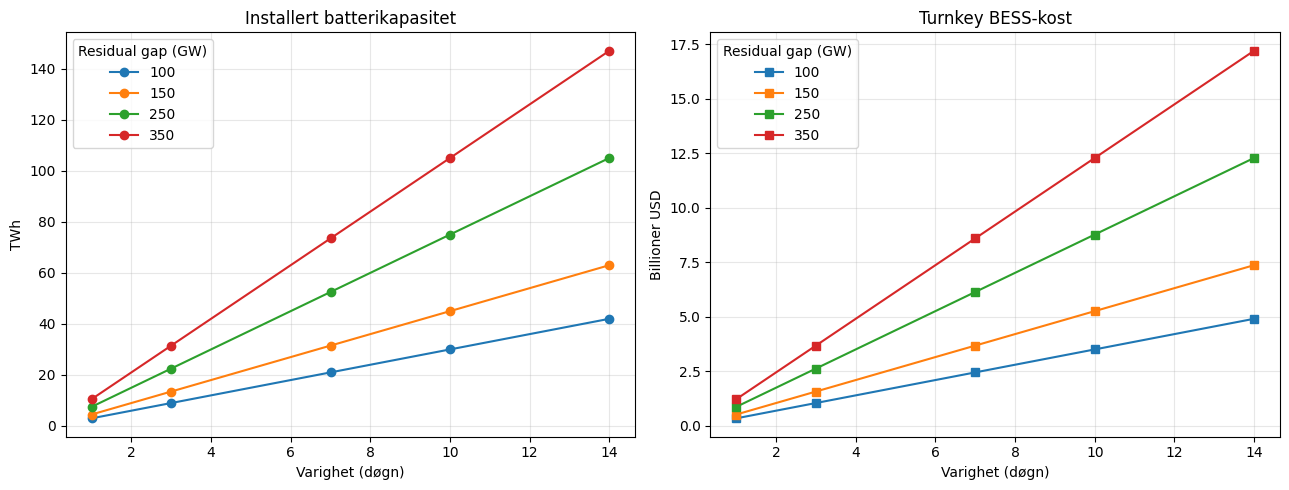

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

pivot.T.plot(marker="o", ax=axes[0])
axes[0].set_title("Installert batterikapasitet")
axes[0].set_xlabel("Varighet (døgn)")
axes[0].set_ylabel("TWh")
axes[0].grid(True, alpha=0.3)

cost_pivot = scenarios.pivot(index="Residual gap (GW)", columns="Døgn", values="Turnkey kost (billioner USD)")
cost_pivot.T.plot(marker="s", ax=axes[1])
axes[1].set_title("Turnkey BESS-kost")
axes[1].set_xlabel("Varighet (døgn)")
axes[1].set_ylabel("Billioner USD")
axes[1].grid(True, alpha=0.3)

for ax in axes:
    ax.legend(title="Residual gap (GW)")

plt.tight_layout()
plt.show()


## Interaktiv lekeplass

Bruk glidebryterne til å teste egne antakelser. Noen nyttige eksperimenter:

- Halver residual gap: hva skjer hvis kraftsystemet har mye regulerbar produksjon og fleksibilitet?
- Øk varigheten: hvor raskt går modellen fra «stor investering» til «industriell mobilisering»?
- Øk natrium-ion-andelen: hjelper det på litiumbehovet, og hva står igjen av kost/supply-chain?
- Senk kost per kWh: hvor billig må batterier bli før multi-døgn-buffer blir rasjonell?

In [7]:
try:
    import ipywidgets as widgets
    from IPython.display import display, Markdown

    residual_gap = widgets.FloatSlider(value=250, min=50, max=500, step=10, description="Residual GW", continuous_update=False)
    days = widgets.FloatSlider(value=10, min=0.5, max=21, step=0.5, description="Døgn", continuous_update=False)
    usable = widgets.FloatSlider(value=0.80, min=0.50, max=0.95, step=0.05, description="Utnyttbar", continuous_update=False)
    pack_cost = widgets.FloatSlider(value=70, min=20, max=200, step=5, description="Pack $/kWh", continuous_update=False)
    turnkey_cost = widgets.FloatSlider(value=117, min=40, max=300, step=5, description="Turnkey $/kWh", continuous_update=False)
    lfp = widgets.FloatSlider(value=0.75, min=0, max=1, step=0.05, description="LFP", continuous_update=False)
    sodium = widgets.FloatSlider(value=0.15, min=0, max=1, step=0.05, description="Na-ion", continuous_update=False)
    other = widgets.FloatSlider(value=0.10, min=0, max=1, step=0.05, description="Andre", continuous_update=False)
    cell_capacity = widgets.FloatSlider(value=3.0, min=1, max=10, step=0.5, description="Global TWh/år", continuous_update=False)
    eu_bess = widgets.FloatSlider(value=27.1, min=10, max=500, step=10, description="EU GWh/år", continuous_update=False)

    controls = {
        "residual_gap_gw": residual_gap,
        "event_days": days,
        "usable_fraction": usable,
        "pack_cost_usd_per_kwh": pack_cost,
        "turnkey_cost_usd_per_kwh": turnkey_cost,
        "lfp_share": lfp,
        "sodium_ion_share": sodium,
        "other_long_duration_share": other,
        "global_cell_capacity_twh_per_year": cell_capacity,
        "eu_bess_additions_gwh_per_year": eu_bess,
    }

    def show(**kwargs):
        r = calculate(**kwargs)
        display(Markdown(
            f"""
### Resultat

- **Installert batterikapasitet:** {r['installed_battery_twh']:.1f} TWh  
- **Levert energi under hendelsen:** {r['delivered_energy_twh']:.1f} TWh  
- **Turnkey BESS-kost:** {r['turnkey_cost_trillion_usd']:.1f} billioner USD  
- **LFP-del:** {r['lfp_twh']:.1f} TWh  
- **Natrium-ion-del:** {r['sodium_ion_twh']:.1f} TWh  
- **Litiumbehov for LFP:** {r['lithium_required_million_tonnes']:.1f} millioner tonn Li  
- **År av 2025-litiumproduksjon:** {r['years_of_2025_lithium_production']:.1f} år  
- **År av global cellekapasitet:** {r['years_of_global_cell_capacity']:.1f} år  
- **Ganger EU BESS-tilvekst 2025:** {r['multiples_of_2025_eu_bess_additions']:.0f}x
            """
        ))
        display(pretty_result(r))

    ui = widgets.VBox([
        widgets.HTML("<b>Hendelse og drift</b>"),
        widgets.HBox([residual_gap, days, usable]),
        widgets.HTML("<b>Kost</b>"),
        widgets.HBox([pack_cost, turnkey_cost]),
        widgets.HTML("<b>Kjemimiks. Verdiene normaliseres automatisk til 100 %.</b>"),
        widgets.HBox([lfp, sodium, other]),
        widgets.HTML("<b>Supply-chain referanser</b>"),
        widgets.HBox([cell_capacity, eu_bess]),
    ])
    out = widgets.interactive_output(show, controls)
    display(ui, out)
except Exception as e:
    print("ipywidgets er ikke tilgjengelig. Kjør tabellene over, eller installer requirements.txt.")
    print(e)

Output()

## Hva natrium-ion faktisk endrer

Natrium-ion kan være viktig fordi det reduserer direkte litiumavhengighet i den delen av miksen som flyttes fra LFP til natrium-ion. I denne modellen ser du det ved å øke `Na-ion` og redusere `LFP`.

Men merk hva natrium-ion **ikke** endrer direkte:

- residual effektmangel i GW
- hendelsens varighet
- behovet for installert TWh
- nettilknytning, invertere, transformatorer og kontrollsystemer
- kapitalbinding for et sjelden brukt lager
- behovet for en moden industriell verdikjede

Derfor er natrium-ion en mulig forbedring av batterilaget, ikke en automatisk løsning på Dunkelflaute.

,LFP-andel,Na-ion-andel,Andre-andel,Installert TWh,"Litiumbehov, Mt Li",År 2025-litiumprod.,"Turnkey kost, $T"
0,1.00,0.00,0.0,75.0,6.7500,23.275862,8.775
1,0.75,0.25,0.0,75.0,5.0625,17.456897,8.775
2,0.50,0.50,0.0,75.0,3.3750,11.637931,8.775
3,0.25,0.75,0.0,75.0,1.6875,5.818966,8.775
4,0.00,1.00,0.0,75.0,0.0000,0.000000,8.775


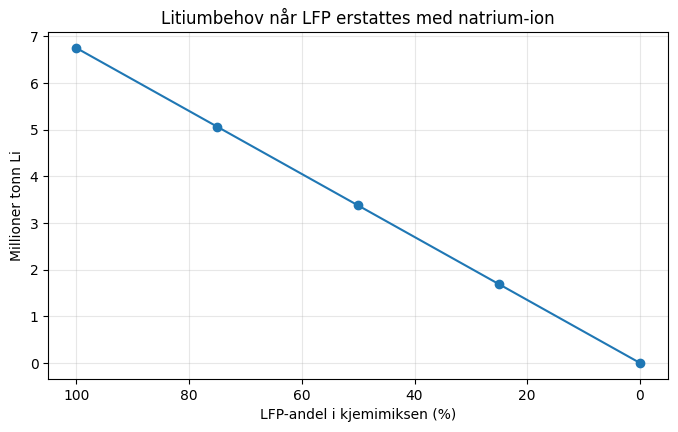

In [8]:
def compare_chemistry(lfp_values=(1.0, 0.75, 0.50, 0.25, 0.0), sodium_value=None):
    rows = []
    for lfp_share in lfp_values:
        if sodium_value is None:
            sodium_share = 1.0 - lfp_share
            other_share = 0.0
        else:
            sodium_share = sodium_value
            other_share = max(0.0, 1.0 - lfp_share - sodium_share)
        r = calculate(lfp_share=lfp_share, sodium_ion_share=sodium_share, other_long_duration_share=other_share)
        rows.append({
            "LFP-andel": r["lfp_share_normalized"],
            "Na-ion-andel": r["sodium_ion_share_normalized"],
            "Andre-andel": r["other_long_duration_share_normalized"],
            "Installert TWh": r["installed_battery_twh"],
            "Litiumbehov, Mt Li": r["lithium_required_million_tonnes"],
            "År 2025-litiumprod.": r["years_of_2025_lithium_production"],
            "Turnkey kost, $T": r["turnkey_cost_trillion_usd"],
        })
    return pd.DataFrame(rows)

chemistry = compare_chemistry()
display(chemistry)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(chemistry["LFP-andel"] * 100, chemistry["Litiumbehov, Mt Li"], marker="o", label="Litiumbehov")
ax.set_title("Litiumbehov når LFP erstattes med natrium-ion")
ax.set_xlabel("LFP-andel i kjemimiksen (%)")
ax.set_ylabel("Millioner tonn Li")
ax.grid(True, alpha=0.3)
ax.invert_xaxis()
plt.show()


## Nøytral konklusjon

Denne modellen bør ikke brukes til å avvise batterier. Den bør brukes til å plassere dem riktig.

En plausibel systemdeling er:

- **sekunder–timer:** batterier er svært sterke
- **timer–ett døgn:** batterier, pumpekraft, fleksibel last og nett kan konkurrere
- **flere døgn:** batterier blir fort svært kapital- og materialkrevende
- **uker–sesong:** dette ligner mer på strategisk energilager, regulerbar produksjon og kjemiske/termiske lagre enn vanlig BESS

Hvis en påstand sier at «natrium-batterier tilgjengelig i dag løser Dunkelflaute», er denne modellen en måte å teste den på. Ikke ved retorikk, men ved TWh, kroner, produksjonskapasitet og materialflyt.

## Videre arbeid

Hver naturlig utvidelse er løftet til en egen, kjørbar notebook under [`extensions/`](extensions):

1. [`01_timeprofiler.ipynb`](extensions/01_timeprofiler.ipynb) — timeprofiler for last, vind og sol.
2. [`02_effekt_vs_energi.ipynb`](extensions/02_effekt_vs_energi.ipynb) — skille effektkapasitet (GW) fra energikapasitet (GWh/TWh).
3. [`03_vannmagasin_pumpekraft.ipynb`](extensions/03_vannmagasin_pumpekraft.ipynb) — eksisterende vannmagasin og pumpekraft.
4. [`04_andre_teknologier.ipynb`](extensions/04_andre_teknologier.ipynb) — kjernekraft, gass+CCS, hydrogen, ammoniakk og syntetisk metan som separate lag.
5. [`05_ladevindu.ipynb`](extensions/05_ladevindu.ipynb) — modellér ladevinduet før/etter hendelsen.
6. [`06_overforing_regioner.ipynb`](extensions/06_overforing_regioner.ipynb) — land/regioner og overføringsbegrensninger.
7. [`07_levetidskost_per_mwh.ipynb`](extensions/07_levetidskost_per_mwh.ipynb) — levetidskost per faktisk levert MWh for sjeldne hendelser.

Den viktigste læringen fra enkel modell er ofte hva en mer avansert modell **må** inneholde.
